In [1]:
# === Core Python Utilities ===
import os
import re
import math
import random
import warnings
from datetime import datetime
from itertools import combinations
from collections import Counter
from typing import List, Tuple, Dict, Optional

# === Scientific Computing ===
import numpy as np
import pandas as pd
import scipy
from scipy.stats import skew

# === Visualization ===
import matplotlib.pyplot as plt
import seaborn as sns
import missingno
import mplcursors
from matplotlib.colors import LinearSegmentedColormap

# === Progress & Optimization ===
from tqdm.notebook import tqdm
tqdm.pandas()
import optuna

# === Data Preprocessing ===
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, PowerTransformer,
    OneHotEncoder, LabelEncoder, OrdinalEncoder
)
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectFromModel
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.manifold import TSNE


# === Train/Test Splits & Cross-Validation ===
from sklearn.model_selection import (
    train_test_split, KFold, StratifiedKFold,
    cross_val_predict, cross_val_score,
    GridSearchCV, RandomizedSearchCV, ParameterGrid
)

# === Metrics & Evaluation ===
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, auc, roc_curve,
    classification_report, confusion_matrix,
    precision_recall_curve, make_scorer
)

from sklearn.decomposition import PCA
# === Pipelines ===
from sklearn.pipeline import make_pipeline

# === Machine Learning Models ===
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.neural_network import MLPClassifier

from xgboost import XGBClassifier
import xgboost as xgb

from lightgbm import LGBMClassifier
import lightgbm as lgb
from catboost import CatBoostClassifier

# from catboost import CatBoostClassifier, CatBoostRegressor, Pool, cv
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
import optuna

In [4]:
from training_module import (
    evaluate_model,                     # Hàm thực hiện đánh giá mô hình trên tập dev và test
    optimize_threshold_by_f1           # Hàm thực hiện tối ưu hoá ngưỡng phân loại
)

In [2]:
# Một số setting cơ bản
import warnings
import pandas as pd
warnings.filterwarnings ('ignore')
pd.set_option ('display.width', None)
pd.set_option ('display.max_rows', 100)
pd.set_option ('display.max_columns', 50)

In [3]:
file_path = '/Users/kittnguyen/Documents/us-flight-project/data/silver_data/'
X_train = np.load(f"{file_path}train/X_train.npy", allow_pickle=True)
y_train = np.load(f"{file_path}train/y_train.npy", allow_pickle=True)
X_dev = np.load(f"{file_path}dev/X_dev.npy", allow_pickle=True)
y_dev = np.load(f"{file_path}dev/y_dev.npy", allow_pickle=True)
X_test = np.load(f"{file_path}test/X_test.npy", allow_pickle=True)
y_test = np.load(f"{file_path}test/y_test.npy", allow_pickle=True)

# LightGBM

## a. Training

In [8]:
# --- LightGBM Classifier ---
lgbm_model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=63,             # thường khoảng 2^(max_depth)
    max_depth=-1,              # để LightGBM tự xác định
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_samples=20,
    reg_lambda=1.0,
    reg_alpha=0.0,
    class_weight={0: 1, 1: 2},        # tự điều chỉnh nếu mất cân bằng lớp
    random_state=42,
    n_jobs=-1
)

# --- Training ---
lgbm_model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 1533455, number of negative: 2512587
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.189046 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3863
[LightGBM] [Info] Number of data points in the train set: 4046042, number of used features: 65
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.549675 -> initscore=0.199358
[LightGBM] [Info] Start training from score 0.199358


,boosting_type,'gbdt'
,num_leaves,63
,max_depth,-1
,learning_rate,0.05
,n_estimators,500
,subsample_for_bin,200000
,objective,None
,class_weight,"{0: 1, 1: 2}"
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


## b. Predicting & Evaluation

### Dev

Evaluation on  set:
Accuracy : 0.6487
Precision: 0.5268
Recall   : 0.7204
F1-score : 0.6086
ROC AUC  : 0.7287


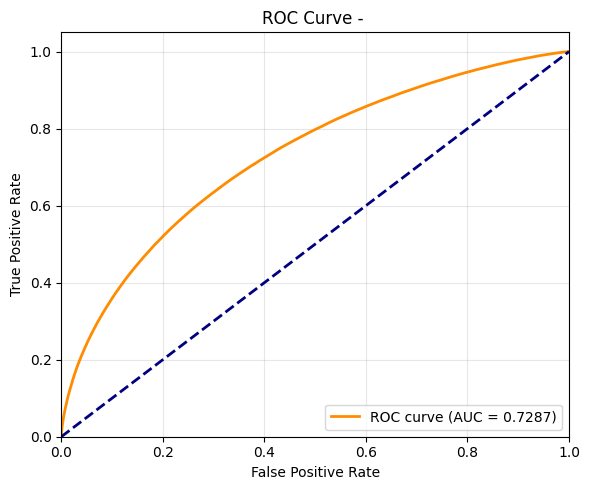

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.60      0.68    837529
           1       0.53      0.72      0.61    511152

    accuracy                           0.65   1348681
   macro avg       0.65      0.66      0.65   1348681
weighted avg       0.68      0.65      0.65   1348681



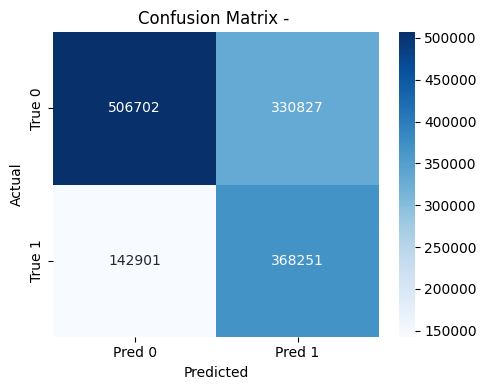

Best threshold: 0.50 with F1-score: 1.0000


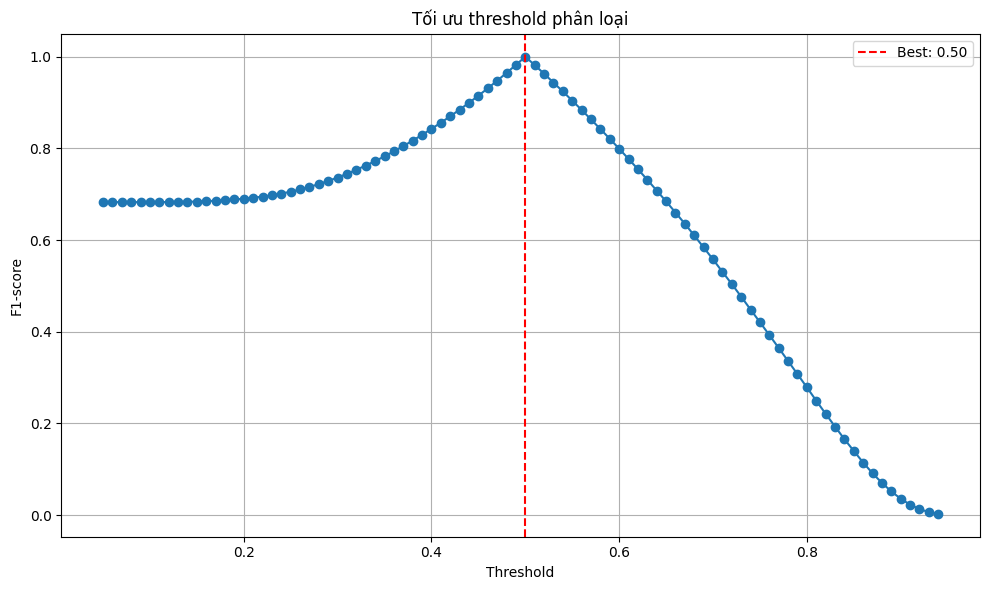

(np.float64(0.5000000000000001), 1.0)

In [9]:
# --- Predicting ---
y_pred_dev = lgbm_model.predict(X_dev)
y_proba_dev = lgbm_model.predict_proba(X_dev)[:, 1] # Probability

# --- Evaluating ---
evaluate_model (y_dev, y_pred_dev, y_proba_dev)

# --- Optimizing ---
optimize_threshold_by_f1 (lgbm_model, X_dev, y_pred_dev)

### Test

Evaluation on  set:
Accuracy : 0.6492
Precision: 0.5272
Recall   : 0.721
F1-score : 0.6091
ROC AUC  : 0.7292


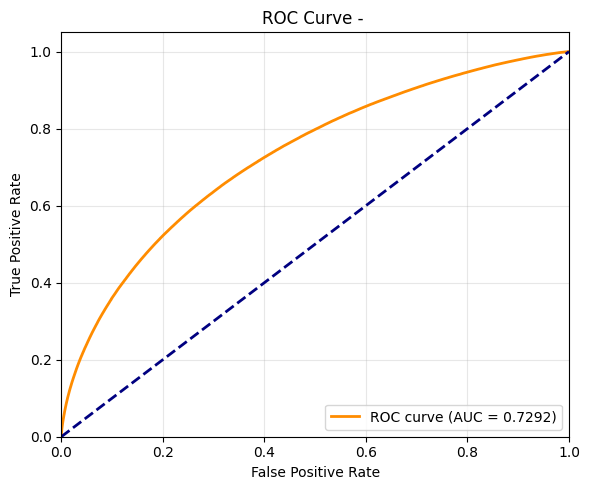

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.61      0.68    837529
           1       0.53      0.72      0.61    511152

    accuracy                           0.65   1348681
   macro avg       0.65      0.66      0.65   1348681
weighted avg       0.68      0.65      0.65   1348681



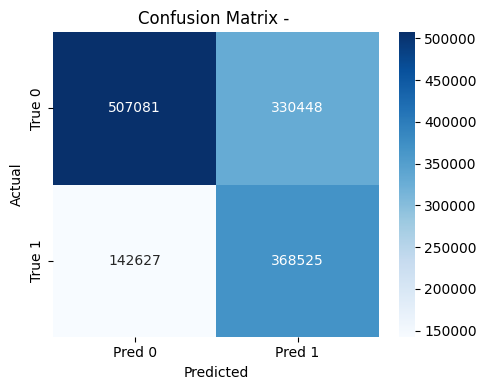

Best threshold: 0.50 with F1-score: 1.0000


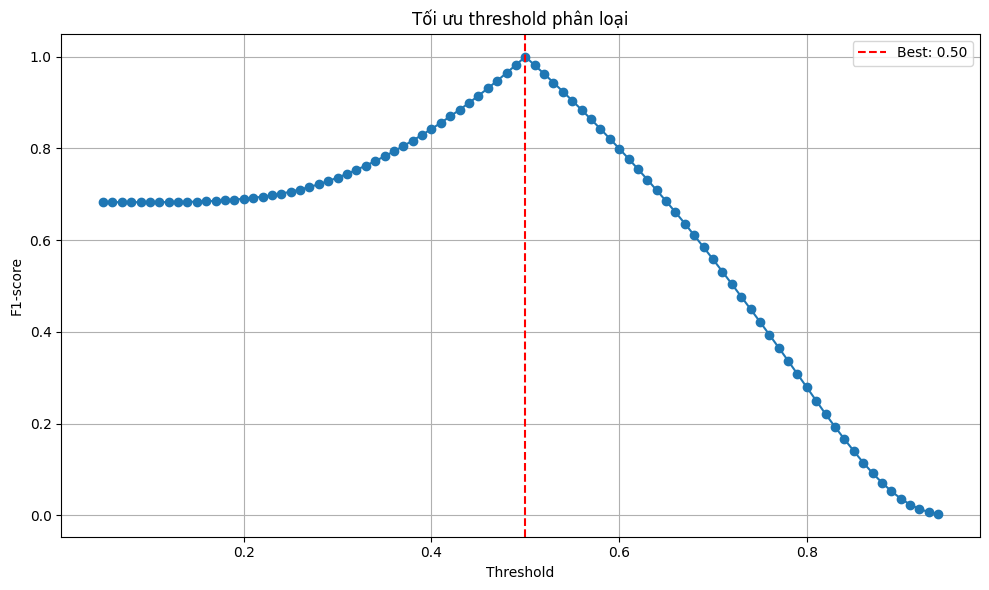

(np.float64(0.5000000000000001), 1.0)

In [10]:
# --- Predicting ---
y_pred_test = lgbm_model.predict(X_test)
y_proba_test = lgbm_model.predict_proba(X_test)[:, 1] # Probability

# --- Evaluating ---
evaluate_model (y_test, y_pred_test, y_proba_test)

# --- Optimizing ---
optimize_threshold_by_f1 (lgbm_model, X_test, y_pred_test)